# Importing Necessary Libraries

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve


# Graph-Based SLAM

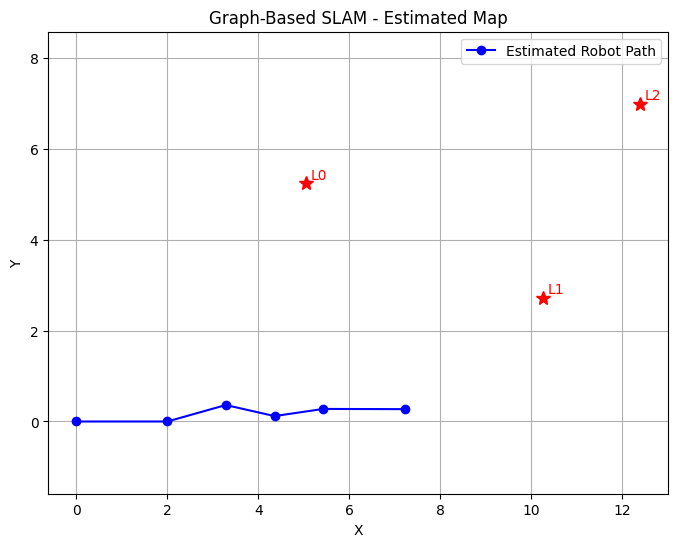

In [6]:
# -------------------------------
# Helper Functions
# -------------------------------

def motion_model(x, u):
    """Applies motion command u = [dx, dy, dtheta] to pose x"""
    return x + u

def measurement_model(x, landmark_pos):
    """Computes the expected measurement to a landmark"""
    dx = landmark_pos[0] - x[0]
    dy = landmark_pos[1] - x[1]
    return np.array([dx, dy])

# -------------------------------
# Simulation Setup
# -------------------------------

# Initial robot pose: [x, y, theta]
poses = [np.array([0.0, 0.0, 0.0])]

# Simulated landmark positions
landmarks = {
    0: np.array([2.0, 3.0]),
    1: np.array([5.0, 1.0]),
    2: np.array([6.0, 4.0])
}

# Simulated odometry: move 5 steps
odometry = [
    np.array([1.0, 0.0, 0.0]),
    np.array([1.0, 0.2, 0.0]),
    np.array([1.0, -0.1, 0.0]),
    np.array([1.0, 0.1, 0.0]),
    np.array([1.0, 0.0, 0.0]),
]

# Build poses based on odometry
for u in odometry:
    new_pose = motion_model(poses[-1], u)
    poses.append(new_pose)

# Simulated observations: (step_index, landmark_id, dx, dy)
observations = [
    (1, 0, 1.0, 3.0),
    (2, 1, 4.0, 1.0),
    (3, 2, 5.0, 3.5),
    (4, 0, 2.0, 3.0),
    (5, 1, 3.5, 1.1),
]

# -------------------------------
# Graph Optimization Setup
# -------------------------------

num_poses = len(poses)
num_landmarks = len(landmarks)
state_size = num_poses * 3 + num_landmarks * 2

# Initial guess of state vector
state = np.zeros(state_size)

# Fill in poses
for i, pose in enumerate(poses):
    state[i*3:i*3+3] = pose

# Fill in landmarks (initial guess with noise)
offset = num_poses * 3
for i, lm in landmarks.items():
    state[offset + i*2:offset + i*2 + 2] = lm + np.random.randn(2) * 0.5

# Build linear system Hx = b
H = lil_matrix((state_size, state_size))
b = np.zeros(state_size)

# -------------------------------
# Anchor the First Pose
# -------------------------------

# Strong prior to fix pose 0
for k in range(3):  # x, y, theta
    H[k, k] += 1e6
    b[k] += 1e6 * state[k]

# -------------------------------
# Constraint Functions
# -------------------------------

def add_odometry_constraint(i, j, u, information=1.0):
    """Adds odometry constraint between pose i and j"""
    idx_i = i * 3
    idx_j = j * 3
    for k in range(3):
        H[idx_i + k, idx_i + k] += information
        H[idx_j + k, idx_j + k] += information
        H[idx_i + k, idx_j + k] -= information
        H[idx_j + k, idx_i + k] -= information
        b[idx_i + k] -= information * u[k]
        b[idx_j + k] += information * u[k]

def add_measurement_constraint(pose_idx, lm_idx, meas, information=1.0):
    """Adds measurement constraint between pose and landmark"""
    idx_pose = pose_idx * 3
    idx_lm = num_poses * 3 + lm_idx * 2
    for k in range(2):
        H[idx_pose + k, idx_pose + k] += information
        H[idx_lm + k, idx_lm + k] += information
        H[idx_pose + k, idx_lm + k] -= information
        H[idx_lm + k, idx_pose + k] -= information
        b[idx_pose + k] -= information * meas[k]
        b[idx_lm + k] += information * meas[k]

# -------------------------------
# Add Constraints to Graph
# -------------------------------

for i in range(len(odometry)):
    add_odometry_constraint(i, i+1, odometry[i])

for obs in observations:
    add_measurement_constraint(obs[0], obs[1], np.array([obs[2], obs[3]]))

# -------------------------------
# Solve system Hx = b
# -------------------------------

dx = spsolve(H.tocsr(), b)
state_estimate = state + dx

# -------------------------------
# Plotting Results
# -------------------------------

# Extract estimated poses and landmarks
est_poses = []
for i in range(num_poses):
    est_poses.append(state_estimate[i*3:i*3+2])

est_landmarks = []
for i in range(num_landmarks):
    est_landmarks.append(state_estimate[offset + i*2:offset + i*2 + 2])

est_poses = np.array(est_poses)
est_landmarks = np.array(est_landmarks)

plt.figure(figsize=(8, 6))
plt.plot(est_poses[:, 0], est_poses[:, 1], 'bo-', label='Estimated Robot Path')
for i, pos in enumerate(est_landmarks):
    plt.plot(pos[0], pos[1], 'r*', markersize=10)
    plt.text(pos[0]+0.1, pos[1]+0.1, f"L{i}", color='r')
plt.title("Graph-Based SLAM - Estimated Map")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.legend()
plt.axis("equal")
plt.show()


# EKF SLAM

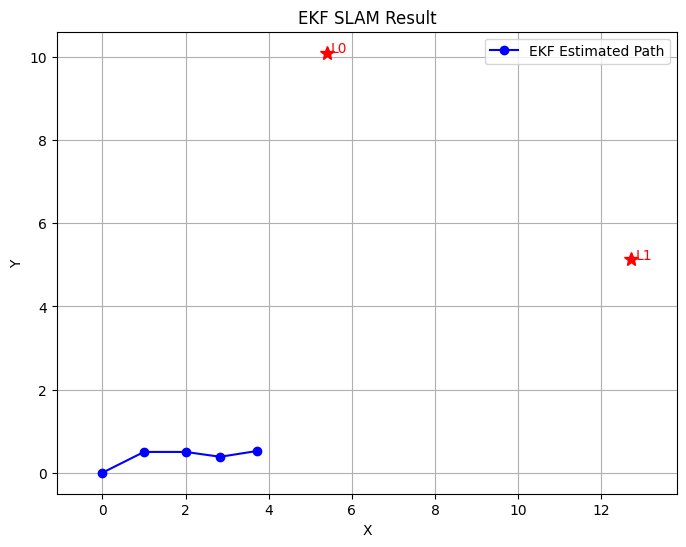

In [7]:
np.random.seed(42)

# -------------------------------
# Setup
# -------------------------------

# Initial pose
mu = np.array([0.0, 0.0])  # x, y
landmarks = {
    0: np.array([5.0, 10.0]),
    1: np.array([12.0, 5.0])
}
num_landmarks = len(landmarks)

# State: robot pose + landmarks (x, y for each)
state_dim = 2 + 2 * num_landmarks
mu_full = np.zeros(state_dim)
mu_full[0:2] = mu

# Initial covariance
Sigma = np.eye(state_dim) * 1000
Sigma[0:2, 0:2] = 0.1 * np.eye(2)  # low uncertainty on initial pose

# Odometry commands
controls = [
    np.array([1.0, 0.5]),
    np.array([1.0, 0.0]),
    np.array([1.0, -0.2]),
    np.array([1.0, 0.1])
]

# Observations: (step_index, landmark_id, x_rel, y_rel)
observations = [
    (1, 0, 4.0, 9.8),
    (2, 1, 10.5, 4.7),
    (3, 0, 3.0, 9.5),
    (4, 1, 9.3, 4.5),
]

# -------------------------------
# EKF Functions
# -------------------------------

def motion_model(mu, u):
    return mu + u  # simple linear motion

def jacobian_motion():
    return np.eye(state_dim)

def measurement_model(mu, lm_index):
    idx = 2 + lm_index * 2
    dx = mu[idx] - mu[0]
    dy = mu[idx+1] - mu[1]
    return np.array([dx, dy])

def jacobian_measurement(mu, lm_index):
    idx = 2 + lm_index * 2
    H = np.zeros((2, state_dim))
    H[:, 0:2] = -np.eye(2)
    H[:, idx:idx+2] = np.eye(2)
    return H

R = np.eye(2) * 0.1  # motion noise
Q = np.eye(2) * 0.5  # measurement noise

# -------------------------------
# EKF SLAM Loop
# -------------------------------

poses = [mu.copy()]

for t, u in enumerate(controls):
    # --- Prediction ---
    G = jacobian_motion()
    mu_full[0:2] = motion_model(mu_full[0:2], u)
    Sigma = G @ Sigma @ G.T + np.block([
        [R, np.zeros((2, state_dim-2))],
        [np.zeros((state_dim-2, 2)), np.zeros((state_dim-2, state_dim-2))]
    ])

    # --- Measurement update ---
    for obs in observations:
        if obs[0] != t + 1:
            continue

        lm_idx = obs[1]
        z = np.array([obs[2], obs[3]])

        # Initialize landmark if needed
        lm_pos_idx = 2 + lm_idx * 2
        if np.all(mu_full[lm_pos_idx:lm_pos_idx+2] == 0):
            mu_full[lm_pos_idx:lm_pos_idx+2] = mu_full[0:2] + z

        z_hat = measurement_model(mu_full, lm_idx)
        H = jacobian_measurement(mu_full, lm_idx)

        S = H @ Sigma @ H.T + Q
        K = Sigma @ H.T @ np.linalg.inv(S)

        mu_full = mu_full + K @ (z - z_hat)
        Sigma = (np.eye(state_dim) - K @ H) @ Sigma

    poses.append(mu_full[0:2].copy())

# -------------------------------
# Plot results
# -------------------------------

poses = np.array(poses)

plt.figure(figsize=(8, 6))
plt.plot(poses[:, 0], poses[:, 1], 'bo-', label="EKF Estimated Path")
for i in range(num_landmarks):
    idx = 2 + i * 2
    plt.plot(mu_full[idx], mu_full[idx+1], 'r*', markersize=10)
    plt.text(mu_full[idx]+0.1, mu_full[idx+1], f"L{i}", color='r')
plt.title("EKF SLAM Result")
plt.grid(True)
plt.axis("equal")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()


# FastSLAM

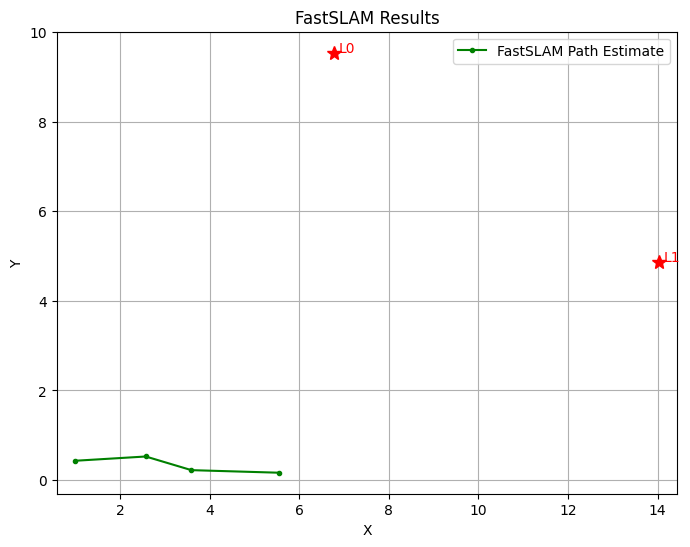

In [8]:
np.random.seed(42)

# -------------------------------
# Setup
# -------------------------------

num_particles = 20
num_landmarks = 2
motion_noise = 0.2
measurement_noise = 0.5

# Controls
controls = [
    np.array([1.0, 0.5]),
    np.array([1.0, 0.0]),
    np.array([1.0, -0.2]),
    np.array([1.0, 0.1])
]

# Simulated observations: (step, landmark_id, x_rel, y_rel)
observations = [
    (1, 0, 4.0, 9.8),
    (2, 1, 10.5, 4.7),
    (3, 0, 3.0, 9.5),
    (4, 1, 9.3, 4.5),
]

# -------------------------------
# Particle class
# -------------------------------

class Particle:
    def __init__(self):
        self.pose = np.zeros(2)
        self.weight = 1.0
        self.landmarks = {}  # {id: [mu, sigma]}

    def motion_update(self, control):
        dx = control + np.random.randn(2) * motion_noise
        self.pose += dx

    def measurement_update(self, obs):
        step, lm_id, mx, my = obs
        z = np.array([mx, my])
        lm_rel = self.pose + z

        if lm_id not in self.landmarks:
            # Initialize landmark
            self.landmarks[lm_id] = [lm_rel, np.eye(2) * 1.0]
        else:
            mu, sigma = self.landmarks[lm_id]
            H = np.eye(2)
            Q = np.eye(2) * measurement_noise
            z_hat = mu - self.pose
            S = H @ sigma @ H.T + Q
            K = sigma @ H.T @ np.linalg.inv(S)
            mu = mu + K @ (z - z_hat)
            sigma = (np.eye(2) - K @ H) @ sigma
            self.landmarks[lm_id] = [mu, sigma]

            # Update weight using likelihood
            diff = z - z_hat
            self.weight *= np.exp(-0.5 * diff.T @ np.linalg.inv(S) @ diff)

# -------------------------------
# FastSLAM Loop
# -------------------------------

particles = [Particle() for _ in range(num_particles)]
poses_all = []

for t, u in enumerate(controls):
    # Motion update for all particles
    for p in particles:
        p.motion_update(u)

    # Measurement update
    for obs in observations:
        if obs[0] != t + 1:
            continue
        for p in particles:
            p.measurement_update(obs)

    # Normalize weights
    weights = np.array([p.weight for p in particles])
    weights += 1e-300  # avoid divide by zero
    weights /= np.sum(weights)

    # Resample
    indices = np.random.choice(range(num_particles), size=num_particles, p=weights)
    particles = [particles[i] for i in indices]
    for p in particles:
        p.weight = 1.0

    # Store estimated pose
    mean_pose = np.mean([p.pose for p in particles], axis=0)
    poses_all.append(mean_pose)

# -------------------------------
# Plotting
# -------------------------------

poses_all = np.array(poses_all)

plt.figure(figsize=(8, 6))
plt.plot(poses_all[:, 0], poses_all[:, 1], 'g.-', label="FastSLAM Path Estimate")

# Plot average landmarks
landmark_estimates = {}
for p in particles:
    for lm_id, (mu, _) in p.landmarks.items():
        if lm_id not in landmark_estimates:
            landmark_estimates[lm_id] = []
        landmark_estimates[lm_id].append(mu)

for lm_id, mus in landmark_estimates.items():
    mean_mu = np.mean(mus, axis=0)
    plt.plot(mean_mu[0], mean_mu[1], 'r*', markersize=10)
    plt.text(mean_mu[0]+0.1, mean_mu[1], f"L{lm_id}", color='r')

plt.title("FastSLAM Results")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.axis('equal')
plt.legend()
plt.show()
